In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import optuna
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)
torch.backends.mkldnn.enabled = False
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy



## Task:

Similar to Task 2A, apply two machine learning algorithms to your dataset, but now focus on
predicting a numerical target (i.e. a regression problem). For the basic dataset this means
your choice of two regression algorithms while for the advanced dataset one regression al-
gorithm which is inherently temporal and one which is not. Describe similar details as you
have for the classification problem. Highlight the differences you see between the two types
of prediction tasks

### Algorithm Choice

Non Temporal: XG Boost 

Temporal: LSTM

In [3]:
df_rf = pl.read_csv("data/rf_dataset.csv")
X_lstm = np.load("data/lstm_X.npy")
y_lstm = np.load("data/lstm_y.npy")
lstm_meta = pl.read_csv("data/lstm_meta.csv").with_columns(
    pl.col("date").str.to_date()
)

print(f"RF dataset     : {df_rf.shape}")
print(f"LSTM dataset   : X={X_lstm.shape}, y={y_lstm.shape}")
print(f"Patients       : {df_rf['id'].n_unique()}")

RF dataset     : (1075, 82)
LSTM dataset   : X=(1075, 5, 18), y=(1075,)
Patients       : 27


#### Train Test Split and Data preparation:

In [4]:
ids = df_rf["id"].to_list()

train_idx = []
test_idx = []

In [5]:
for patient_id in sorted(set(ids)):
    patient_indices = [i for i, x in enumerate(ids) if x == patient_id]
    split_point = int(len(patient_indices) * 0.8)
    train_idx.extend(patient_indices[:split_point])
    test_idx.extend(patient_indices[split_point:])

#### XGboost Data

In [19]:
feature_cols = [c for c in df_rf.columns if c not in ["target", "id", "date"]]
X_rf = df_rf.select(feature_cols).to_numpy().astype(float)
y_all = df_rf["target"].to_numpy().astype(float)

X_train_xgb = X_rf[train_idx]
X_test_xgb  = X_rf[test_idx]
y_train = y_all[train_idx]
y_test  = y_all[test_idx]


#### LSTM Data

In [6]:
X_train_lstm = X_lstm[train_idx]
X_test_lstm  = X_lstm[test_idx]
y_train_lstm = y_lstm[train_idx]
y_test_lstm  = y_lstm[test_idx]

#### Baseline Data

In [20]:
bl_lag1 = df_rf["mood_lag1"].to_numpy()[test_idx]
bl_mean = df_rf["mood_mean"].to_numpy()[test_idx]


In [21]:
print(f"Train : {len(train_idx)} samples")
print(f"Test  : {len(test_idx)} samples")
print(f"Features (XGBoost) : {len(feature_cols)}")
print(f"Features (LSTM)    : {X_lstm.shape[2]} per timestep, {X_lstm.shape[1]} timesteps")



Train : 848 samples
Test  : 227 samples
Features (XGBoost) : 79
Features (LSTM)    : 18 per timestep, 5 timesteps


## Baseline

In [22]:
print(f"\n{'Baseline':<25} {'MAE':>8} {'MSE':>8} {'R²':>8}")
print("=" * 52)
for name, preds in [("Last-value (lag1)", bl_lag1), ("Window mean", bl_mean)]:
    print(f"{name:<25} "
          f"{mean_absolute_error(y_test, preds):>8.4f} "
          f"{mean_squared_error(y_test, preds):>8.4f} "
          f"{r2_score(y_test, preds):>8.4f}")


Baseline                       MAE      MSE       R²
Last-value (lag1)           0.4666   0.4420   0.2823
Window mean                 0.4421   0.4080   0.3374


## XG Boost

#### TS CV

In [23]:
tscv = TimeSeriesSplit(n_splits=3)
splits = list(tscv.split(X_train_xgb))

def xgb_objective(trial):
    params = {
        "n_estimators":  trial.suggest_int("n_estimators", 50, 400),
        "max_depth":     trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        "reg_alpha":     trial.suggest_float("reg_alpha", 0.01, 5.0, log=True),
        "reg_lambda":    trial.suggest_float("reg_lambda", 0.01, 5.0, log=True),
    }
    fold_scores = []
    for tr_i, val_i in splits:
        model = XGBRegressor(
            **params,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
        )
        model.fit(X_train_xgb[tr_i], y_train[tr_i])
        preds = model.predict(X_train_xgb[val_i])
        fold_scores.append(mean_absolute_error(y_train[val_i], preds))
    return np.mean(fold_scores)



In [24]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize")
study.optimize(xgb_objective, n_trials=30)

print(f"Best CV MAE : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

Best CV MAE : 0.4914
Best params : {'n_estimators': 118, 'max_depth': 2, 'learning_rate': 0.045793511106704106, 'reg_alpha': 0.2935977047004778, 'reg_lambda': 2.111486900408041}


In [25]:
xgb_model = XGBRegressor(
    **study.best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
xgb_model.fit(X_train_xgb, y_train)

xgb_preds = xgb_model.predict(X_test_xgb)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_r2  = r2_score(y_test, xgb_preds)
print(f"XGBoost Test | MAE: {xgb_mae:.4f}  MSE: {xgb_mse:.4f}  R²: {xgb_r2:.4f}")

XGBoost Test | MAE: 0.4361  MSE: 0.3770  R²: 0.3877


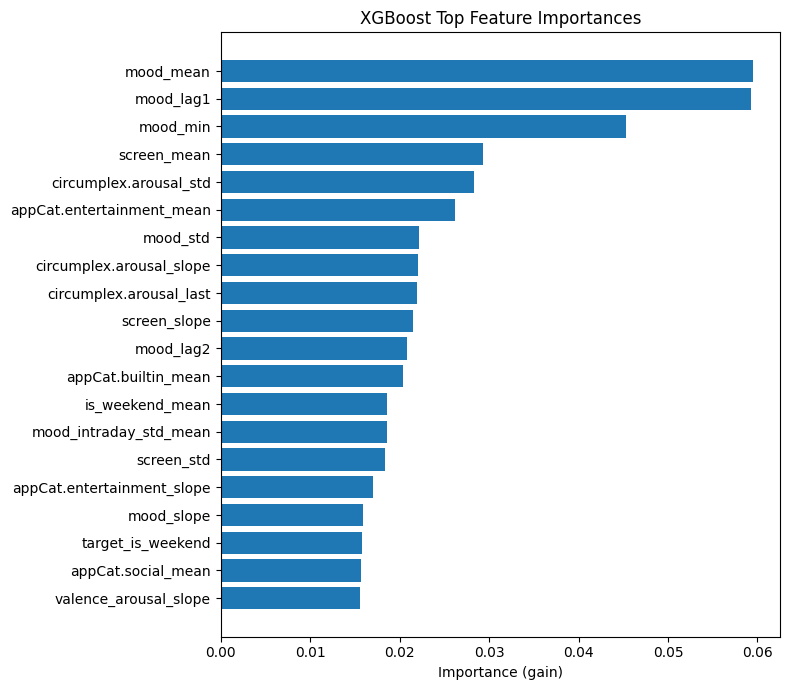

In [26]:
importances = xgb_model.feature_importances_
top_n = 20
order = np.argsort(importances)[-top_n:]

plt.figure(figsize=(8, 7))
plt.barh([feature_cols[i] for i in order], importances[order])
plt.title("XGBoost Top Feature Importances")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.savefig("xgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## LSTM pt 2:

In [7]:
class MoodDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [8]:
class MoodLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = self.dropout(h_n[-1])        # (batch, hidden)
        return self.fc(out).squeeze(-1)     # (batch,)

In [9]:
def train_lstm(config, X_tr, y_tr, X_val, y_val, max_epochs=200, patience=20):
    """Train one LSTM config, return best model + history."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = MoodLSTM(
        input_size=X_tr.shape[2],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10
    )
    criterion = nn.L1Loss()  # MAE

    train_loader = DataLoader(
        MoodDataset(X_tr, y_tr), batch_size=32, shuffle=False
    )
    val_loader = DataLoader(
        MoodDataset(X_val, y_val), batch_size=64, shuffle=False
    )

    best_val_mae = float("inf")
    best_state = None
    patience_ctr = 0
    history = {"train_loss": [], "val_mae": []}

    for epoch in range(max_epochs):
        # Train
        model.train()
        epoch_loss = 0.0
        n_samples = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(y_b)
            n_samples += len(y_b)
        history["train_loss"].append(epoch_loss / n_samples)

        # Validate
        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                preds.extend(model(X_b.to(device)).cpu().numpy())
                actuals.extend(y_b.numpy())
        val_mae = mean_absolute_error(actuals, preds)
        history["val_mae"].append(val_mae)

        scheduler.step(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            break

    model.load_state_dict(best_state)
    return model, history, best_val_mae

In [10]:
torch.manual_seed(42)
np.random.seed(42)

In [11]:
tscv = TimeSeriesSplit(n_splits=3)
splits = list(tscv.split(X_train_lstm))

n_samples, n_steps, n_feats = X_train_lstm.shape

def lstm_objective(trial):
    config = {
        "hidden_size": trial.suggest_categorical("hidden_size", [64, 128, 256]),
        "num_layers":  trial.suggest_int("num_layers", 1, 2),
        "dropout":     trial.suggest_float("dropout", 0.1, 0.3),
        "lr":          trial.suggest_float("lr", 0.0005, 0.005, log=True),
    }

    fold_scores = []
    for tr_i, val_i in splits:
        fold_train = X_train_lstm[tr_i]
        fold_val   = X_train_lstm[val_i]

        flat = fold_train.reshape(-1, n_feats)
        mu  = flat.mean(axis=0)
        std = flat.std(axis=0)
        std[std == 0] = 1

        X_tr_norm  = ((fold_train.reshape(-1, n_feats) - mu) / std).reshape(len(tr_i), n_steps, n_feats)
        X_val_norm = ((fold_val.reshape(-1, n_feats)   - mu) / std).reshape(len(val_i), n_steps, n_feats)

        y_tr_fold  = y_train_lstm[tr_i]
        y_val_fold = y_train_lstm[val_i]

        _, _, val_mae = train_lstm(
            config, X_tr_norm, y_tr_fold, X_val_norm, y_val_fold,
            max_epochs=200, patience=20
        )
        fold_scores.append(val_mae)

    return np.mean(fold_scores)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lstm = optuna.create_study(direction="minimize")
study_lstm.optimize(lstm_objective, n_trials=30)

print(f"Best CV MAE : {study_lstm.best_value:.4f}")
print(f"Best params : {study_lstm.best_params}")

Best CV MAE : 0.4680
Best params : {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1372852324708992, 'lr': 0.003264036355845585}


In [12]:
best_config = study_lstm.best_params

flat = X_train_lstm.reshape(-1, n_feats)
mu  = flat.mean(axis=0)
std = flat.std(axis=0)
std[std == 0] = 1

X_tr_norm = ((X_train_lstm.reshape(-1, n_feats) - mu) / std).reshape(n_samples, n_steps, n_feats)
X_te_norm = ((X_test_lstm.reshape(-1, n_feats)  - mu) / std).reshape(-1, n_steps, n_feats)

val_size = int(n_samples * 0.15)
X_tr_final = X_tr_norm[:-val_size]
y_tr_final = y_train_lstm[:-val_size]
X_val      = X_tr_norm[-val_size:]
y_val      = y_train_lstm[-val_size:]

torch.manual_seed(42)
np.random.seed(42)

best_model, history, val_mae = train_lstm(
    best_config, X_tr_final, y_tr_final, X_val, y_val,
    max_epochs=200, patience=20
)

print(f"Final train MAE : {history['train_loss'][-1]:.4f}")
print(f"Final val MAE   : {val_mae:.4f}")

Final train MAE : 0.3478
Final val MAE   : 0.4352


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = best_model.to(device)
best_model.eval()

test_loader = DataLoader(
    MoodDataset(X_te_norm, y_test_lstm), batch_size=64, shuffle=False
)

preds_list, actuals_list = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds_list.extend(best_model(X_b.to(device)).cpu().numpy())
        actuals_list.extend(y_b.numpy())

lstm_preds  = np.array(preds_list)
lstm_actual = np.array(actuals_list)

lstm_mae = mean_absolute_error(lstm_actual, lstm_preds)
lstm_mse = mean_squared_error(lstm_actual, lstm_preds)
lstm_r2  = r2_score(lstm_actual, lstm_preds)
print(f"LSTM Test | MAE: {lstm_mae:.4f}  MSE: {lstm_mse:.4f}  R²: {lstm_r2:.4f}")

LSTM Test | MAE: 0.5213  MSE: 0.4714  R²: 0.2345


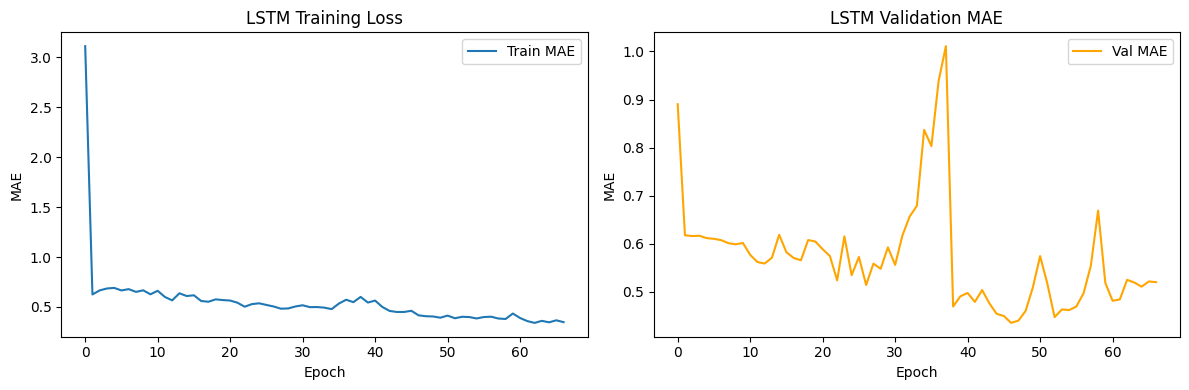

Best config: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1372852324708992, 'lr': 0.003264036355845585}
Final train MAE : 0.3478
Best val MAE    : 0.4352
Gap (val - train): 0.0874
some overfitting


In [17]:
# Training curves
h = history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(h["train_loss"], label="Train MAE")
ax1.set(xlabel="Epoch", ylabel="MAE", title="LSTM Training Loss")
ax1.legend()

ax2.plot(h["val_mae"], color="orange", label="Val MAE")
ax2.set(xlabel="Epoch", ylabel="MAE", title="LSTM Validation MAE")
ax2.legend()

plt.tight_layout()
plt.savefig("lstm_training.png", dpi=150, bbox_inches="tight")
plt.show()

# Overfitting check
print(f"Best config: {best_config}")
print(f"Final train MAE : {h['train_loss'][-1]:.4f}")
print(f"Best val MAE    : {val_mae:.4f}")
gap = val_mae - h["train_loss"][-1]
print(f"Gap (val - train): {gap:.4f}")
if gap > 0.15:
    print("some overfitting present")
elif gap > 0.05:
    print("some overfitting")
else:
    print("no overfitting concern")

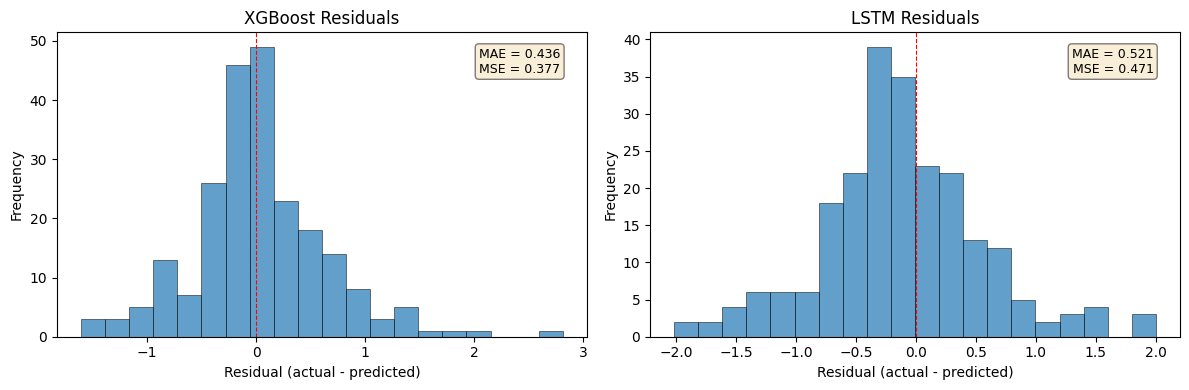

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, actual, preds in [
    (axes[0], "XGBoost", y_test, xgb_preds),
    (axes[1], "LSTM",    lstm_actual, lstm_preds),
]:
    residuals = actual - preds
    ax.hist(residuals, bins=20, edgecolor="black", linewidth=0.5, alpha=0.7)
    ax.axvline(0, color="red", linestyle="--", linewidth=0.8)
    ax.set(xlabel="Residual (actual - predicted)", ylabel="Frequency",
           title=f"{name} Residuals")
    ax.text(0.95, 0.95,
            f"MAE = {np.mean(np.abs(residuals)):.3f}\n"
            f"MSE = {np.mean(residuals**2):.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig("residuals.png", dpi=150, bbox_inches="tight")
plt.show()

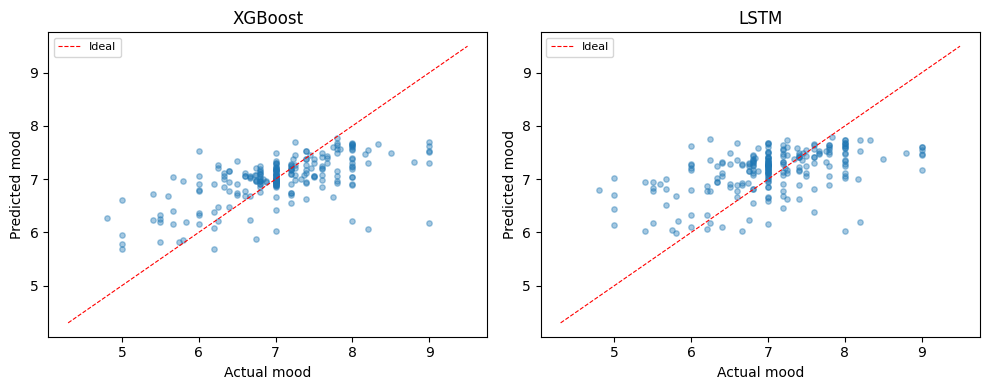

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, actual, preds in [
    (axes[0], "XGBoost", y_test, xgb_preds),
    (axes[1], "LSTM",    lstm_actual, lstm_preds),
]:
    ax.scatter(actual, preds, alpha=0.4, s=15)
    lo = min(actual.min(), preds.min()) - 0.5
    hi = max(actual.max(), preds.max()) + 0.5
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=0.8, label="Ideal")
    ax.set(xlabel="Actual mood", ylabel="Predicted mood", title=name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
print(f"\n{'='*52}")
print(f"{'Model':<25} {'MAE':>8} {'MSE':>8} {'R²':>8}")
print(f"{'='*52}")
for name, actual, preds in [
    ("Last-value baseline", y_test, bl_lag1),
    ("Window-mean baseline", y_test, bl_mean),
    ("XGBoost", y_test, xgb_preds),
    ("LSTM", lstm_actual, lstm_preds),
]:
    print(f"{name:<25} "
          f"{mean_absolute_error(actual, preds):>8.4f} "
          f"{mean_squared_error(actual, preds):>8.4f} "
          f"{r2_score(actual, preds):>8.4f}")


Model                          MAE      MSE       R²
Last-value baseline         0.4666   0.4420   0.2823
Window-mean baseline        0.4421   0.4080   0.3374
XGBoost                     0.4361   0.3770   0.3877
LSTM                        0.5213   0.4714   0.2345
